In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import glob
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_parquet("../data/processed/spy_processed.parquet")

In [3]:
oi_files = sorted(glob.glob("../data/raw/oi/SPY/*.parquet"))
oi = pd.concat([pd.read_parquet(f) for f in oi_files], ignore_index=True)
oi = oi.drop(columns=["symbol", "timestamp"])
oi = oi.drop_duplicates(subset=["expiration", "strike", "right"], keep="first")

In [4]:
total_oi = oi.groupby(["expiration", "strike"])["open_interest"].sum().rename("total_oi")
oi = oi.merge(total_oi, on=["expiration", "strike"], how="left")

In [5]:
max_oi_strike = (
    oi.drop_duplicates(subset=["expiration", "strike"])
    .groupby("expiration")
    .apply(lambda g: g.loc[g["total_oi"].idxmax(), "strike"])
    .rename("max_oi_strike")
    .reset_index()
)
oi = oi.merge(max_oi_strike, on="expiration", how="left")

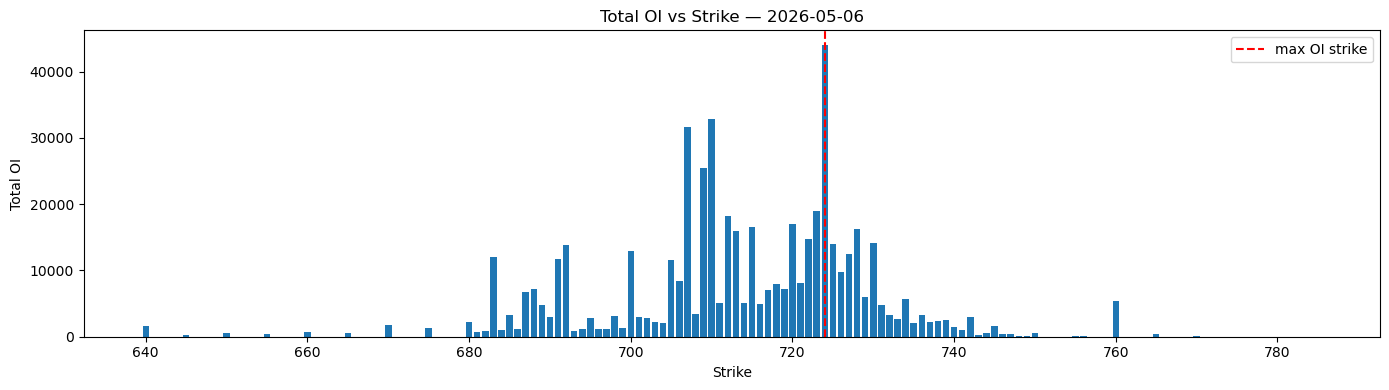

In [6]:
day = oi[oi["expiration"] == "2026-05-06"].drop_duplicates(subset=["strike"])
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(day["strike"], day["total_oi"])
ax.axvline(day["max_oi_strike"].iloc[0], color="red", linestyle="--", label="max OI strike")
ax.set_xlabel("Strike")
ax.set_ylabel("Total OI")
ax.set_title("Total OI vs Strike — 2026-05-06")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
strikes_per_exp = oi.drop_duplicates(subset=["expiration", "strike"])

top3_sum = (
    strikes_per_exp.groupby("expiration")["total_oi"]
    .apply(lambda x: x.nlargest(3).sum())
    .rename("top3_oi_sum")
    .reset_index()
)

day_total = (
    strikes_per_exp.groupby("expiration")["total_oi"]
    .sum()
    .rename("day_total_oi")
    .reset_index()
)

concentration = top3_sum.merge(day_total, on="expiration")
concentration["oi_concentration_top3"] = concentration["top3_oi_sum"] / concentration["day_total_oi"]

oi = oi.merge(concentration[["expiration", "oi_concentration_top3"]], on="expiration", how="left")

In [8]:
put_oi = (
    oi[oi["right"] == "PUT"]
    .set_index(["expiration", "strike"])["open_interest"]
    .rename("put_oi")
)
oi = oi.join(put_oi, on=["expiration", "strike"])
oi["put_oi_fraction"] = oi["put_oi"].div(oi["total_oi"]).where(oi["total_oi"] > 0)
oi = oi.drop(columns="put_oi")

In [9]:
oi["expiration"] = pd.to_datetime(oi["expiration"])

df = df.merge(
    oi.drop(columns="open_interest"),
    on=["expiration", "strike", "right"],
    how="left",
)

df['distance_to_max_oi'] = df['underlying_price'] - df['max_oi_strike']

In [11]:
df['bid_ask_mid'] = (df['ask'] + df['bid']) / 2
df['bid_ask_spread'] = df['ask'] - df['bid']
df['bid_ask_spread_norm'] = df['bid_ask_spread'] / df['bid_ask_mid']

In [13]:
df

,symbol,expiration,strike,right,timestamp,bid,ask,delta,theta,vega,rho,epsilon,lambda,implied_vol,iv_error,underlying_timestamp,underlying_price,spy_close,spy_open,log_return_from_open,ttm_min,log_return,d1,gamma,open_interest,dex,gex,tex,total_oi,max_oi_strike,oi_concentration_top3,put_oi_fraction,distance_to_max_oi,bid_ask_mid,bid_ask_spread,bid_ask_spread_norm
0,SPY,2026-05-06,714.0,CALL,2026-05-06 10:30:00-04:00,16.04,16.11,0.9898,-0.4813,0.4926,0.4436,-0.4537,44.9675,0.3828,0.0000,2026-05-06 10:30:00-04:00,730.03,733.77,728.19,0.002524,330.0,0.005110,2.322163,0.003843,1060,-7.659387e+07,2.171208e+06,51017.80,5123.0,724.0,0.203903,0.793090,6.03,16.075,0.07,0.004355
1,SPY,2026-05-06,714.0,PUT,2026-05-06 09:45:00-04:00,0.04,0.05,-0.0158,-0.5438,0.7730,-0.0082,0.0082,-284.7637,0.3671,0.0142,2026-05-06 09:45:00-04:00,729.15,733.77,728.19,0.001317,375.0,0.006316,2.149100,0.005542,4063,4.680808e+06,-1.197233e+07,220945.94,5123.0,724.0,0.203903,0.793090,5.15,0.045,0.01,0.222222
2,SPY,2026-05-06,714.0,PUT,2026-05-06 10:00:00-04:00,0.04,0.05,-0.0153,-0.5652,0.7359,-0.0076,0.0076,-278.4672,0.3847,0.0027,2026-05-06 10:00:00-04:00,729.66,733.77,728.19,0.002017,360.0,0.005617,2.162660,0.005239,4063,4.535851e+06,-1.133216e+07,229640.76,5123.0,724.0,0.203903,0.793090,5.66,0.045,0.01,0.222222
3,SPY,2026-05-06,714.0,PUT,2026-05-06 10:15:00-04:00,0.04,0.05,-0.0150,-0.5964,0.7115,-0.0072,0.0072,-272.4896,0.4023,0.0100,2026-05-06 10:15:00-04:00,730.08,733.77,728.19,0.002592,345.0,0.005042,2.168482,0.005050,4063,4.449473e+06,-1.093706e+07,242317.32,5123.0,724.0,0.203903,0.793090,6.08,0.045,0.01,0.222222
4,SPY,2026-05-06,714.0,PUT,2026-05-06 10:30:00-04:00,0.03,0.04,-0.0121,-0.4953,0.5764,-0.0055,0.0055,-291.3656,0.3945,0.0126,2026-05-06 10:30:00-04:00,730.03,733.77,728.19,0.002524,330.0,0.005110,2.253582,0.004363,4063,3.588995e+06,-9.447362e+06,201240.39,5123.0,724.0,0.203903,0.793090,6.03,0.035,0.01,0.285714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15647,SPY,2026-05-19,699.0,CALL,2026-05-19 10:45:00-04:00,33.55,34.49,0.9672,-3.2311,1.3139,0.4043,-0.4247,20.8325,1.0542,0.0000,2026-05-19 10:45:00-04:00,732.76,733.77,734.75,-0.002712,315.0,0.001377,1.841479,0.003871,5,-3.543627e+05,1.039286e+04,1615.55,234.0,735.0,0.127169,0.978632,-2.24,34.020,0.94,0.027631
15648,SPY,2026-05-19,699.0,CALL,2026-05-19 11:30:00-04:00,32.73,34.11,0.9759,-2.6762,0.9379,0.3499,-0.3671,21.3840,1.0437,0.0000,2026-05-19 11:30:00-04:00,732.25,733.77,734.75,-0.003408,270.0,0.002074,1.977207,0.003261,5,-3.573014e+05,8.743906e+03,1338.10,234.0,735.0,0.127169,0.978632,-2.75,33.420,1.38,0.041293
15649,SPY,2026-05-19,699.0,CALL,2026-05-19 14:30:00-04:00,36.78,37.48,0.9683,-11.7516,0.6852,0.1156,-0.1220,19.1908,2.1318,0.0000,2026-05-19 14:30:00-04:00,735.87,733.77,734.75,0.001523,90.0,-0.002858,1.856857,0.003466,5,-3.562715e+05,9.385013e+03,5875.80,234.0,735.0,0.127169,0.978632,0.87,37.130,0.70,0.018853
15650,SPY,2026-05-19,699.0,CALL,2026-05-19 15:00:00-04:00,35.20,36.67,0.9473,-29.2194,0.8426,0.0753,-0.0794,19.3649,2.8833,0.0000,2026-05-19 15:00:00-04:00,734.42,733.77,734.75,-0.000449,60.0,-0.000885,1.620110,0.004746,5,-3.478580e+05,1.280053e+04,14609.70,234.0,735.0,0.127169,0.978632,-0.58,35.935,1.47,0.040907
